In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import scipy.stats as stats
from matplotlib.pyplot import figure
from sklearn.linear_model import LogisticRegression

In [2]:
#https://docs.google.com/forms/d/1HPkpNasg4fxGLh-7TFevOSzMPdUpwF6tezt57sW15Mk/viewanalytics

In [61]:
df

,Exam,Jessica,John,Alex
0,Exam 1,77,56,87
1,Exam 2,76,97,82
2,Exam 3,87,95,93


In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df_twice = pd.read_csv('data/Twice Mega Survey 2021.csv')

In [62]:
df = pd.DataFrame(data={'Exam':['Exam 1','Exam 2','Exam 3'],
'Jessica':[77,76,87],'John':[56,97,95],'Alex':[87,82,93]})
df

,Exam,Jessica,John,Alex
0,Exam 1,77,56,87
1,Exam 2,76,97,82
2,Exam 3,87,95,93


In [87]:
bias = "Who is your bias (Favorite Twice Member) or current favorite member (if you don't have a bias)?"
age = "What is your age group?"
filtered_down = df_twice[[age, bias]].value_counts().reset_index().pivot(index=age, columns=bias, values=0).fillna(0)
filtered_down = filtered_down.reindex(index = ['Under 14', '15-17', '18-19', '20-25', '26-30', '30-40', '40+'])
filtered_down.reset_index(inplace=True)

In [88]:
"Chaeyoung", "Dahyun", "Jeongyeon" #	Jihyo	Mina	Momo	Nayeon	Sana	Tzuyu

Who is your bias (Favorite Twice Member) or current favorite member (if you don't have a bias)?,What is your age group?,Chaeyoung,Dahyun,Jeongyeon,Jihyo,Mina,Momo,Nayeon,Sana,Tzuyu
0,Under 14,2.0,3.0,2.0,2.0,2.0,0.0,0.0,2.0,1.0
1,15-17,8.0,20.0,3.0,7.0,2.0,7.0,2.0,8.0,4.0
2,18-19,9.0,15.0,6.0,12.0,10.0,10.0,5.0,14.0,4.0
3,20-25,33.0,48.0,22.0,42.0,63.0,29.0,24.0,58.0,27.0
4,26-30,11.0,35.0,12.0,27.0,37.0,18.0,32.0,28.0,12.0
5,30-40,9.0,23.0,17.0,18.0,20.0,12.0,19.0,32.0,9.0
6,40+,3.0,1.0,4.0,6.0,5.0,1.0,2.0,5.0,1.0


In [96]:
df_twice = pd.read_csv('data/Twice Mega Survey 2021.csv')
bias = "Who is your bias (Favorite Twice Member) or current favorite member (if you don't have a bias)?"
age = "What is your age group?"

filtered_down = df_twice[[age, bias]].value_counts().reset_index().pivot(index=age, columns=bias, values=0).fillna(0)

/Users/nicolascap/anaconda3/lib/python3.10/site-packages/plotly/graph_objs/_deprecations.py:378: DeprecationWarning:

plotly.graph_objs.Line is deprecated.
Please replace it with one of the following more specific types
  - plotly.graph_objs.scatter.Line
  - plotly.graph_objs.layout.shape.Line
  - etc.




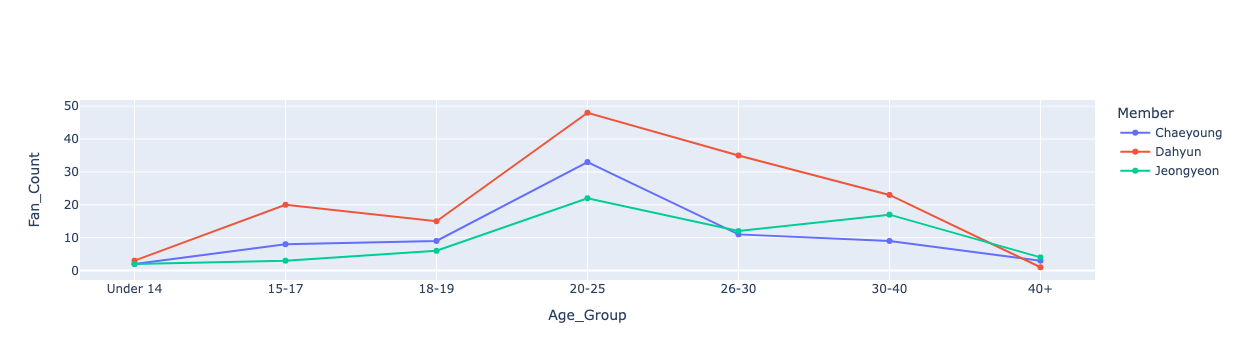

In [95]:
import plotly.graph_objects as go

df_twice = pd.read_csv('data/Twice Mega Survey 2021.csv')
bias = "Who is your bias (Favorite Twice Member) or current favorite member (if you don't have a bias)?"
age = "What is your age group?"

filtered_down = df_twice[[age, bias]].value_counts().reset_index().pivot(index=age, columns=bias, values=0).fillna(0)
filtered_down = filtered_down.reindex(index = ['Under 14', '15-17', '18-19', '20-25', '26-30', '30-40', '40+'])
filtered_down.reset_index(inplace=True)

#fig = go.Figure(data=[
 #   go.Line(name='Jessica', x=df['Exam'], y=df['Jessica']),
#    go.Line(name='John', x=df['Exam'], y=df['John']),
#    go.Line(name='Alex', x=df['Exam'], y=df['Alex'])
#])


fig = go.Figure(data=[
    go.Line(name='Chaeyoung', x=filtered_down[age], y=filtered_down['Chaeyoung']),
    go.Line(name='Dahyun', x=filtered_down[age], y=filtered_down['Dahyun']),
    go.Line(name='Jeongyeon', x=filtered_down[age], y=filtered_down['Jeongyeon'])
])

fig.update_layout(
    xaxis_title='Age_Group',
    yaxis_title='Fan_Count',
    legend_title='Member',
)


In [44]:
x = df_twice.groupby(["Who is your bias (Favorite Twice Member) or current favorite member (if you don't have a bias)?"])['What is your age group?'].value_counts().to_frame()

x.columns



Index(['What is your age group?'], dtype='object')

<Axes: >

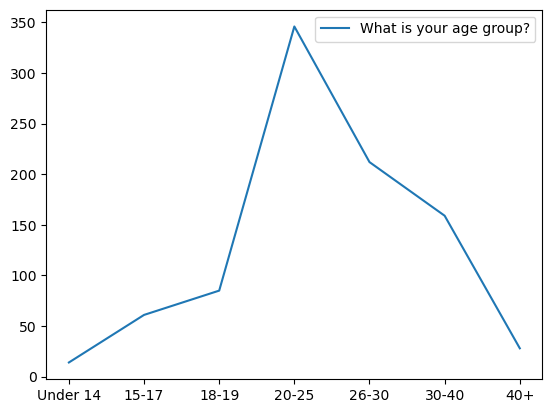

In [58]:
a = 'What is your age group?'
b = "Who is your bias (Favorite Twice Member) or current favorite member (if you don't have a bias)?"
df_twice[a].value_counts().to_frame().reindex(index = ['Under 14', '15-17', '18-19', '20-25', '26-30', '30-40', '40+']).plot(kind='line')

In [ ]:
 .reindex(index = ['Under 14', '15-17', '18-19', '20-25', '26-30', '30-40', '40+'])

<Axes: >

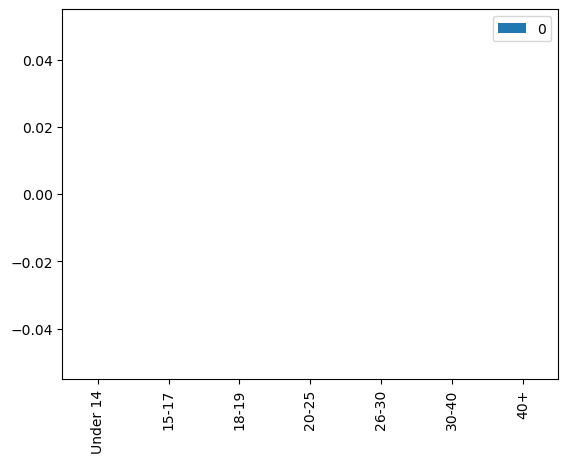

In [55]:
df_twice[[a]].value_counts().to_frame().reindex(index = ['Under 14', '15-17', '18-19', '20-25', '26-30', '30-40', '40+']).plot(kind='bar')

In [25]:
[df_twice.columns[0]] + list(df_twice.columns[1:3])

['Timestamp', 'What is your age group?', 'What is your gender?']

In [26]:
[df_twice.columns[0]] + list(df_twice.columns[3:5])

['Timestamp', 'What is your sexuality?', 'Where do you live?']

In [20]:
df_twice[list(df_twice.columns)[0:5]].head()

,Timestamp,What is your age group?,What is your gender?,What is your sexuality?,Where do you live?
0,12/26/2021 3:47:53,20-25,Female,Gay/Lesbian,North America
1,12/26/2021 17:43:23,30-40,Male,Straight,North America
2,12/26/2021 17:44:02,20-25,Male,Straight,Other European Countries
3,12/26/2021 17:44:32,30-40,Male,Straight,North America
4,12/26/2021 17:46:27,20-25,Male,Straight,North America


In [14]:
df_twice['What is your age group?'].unique() 

array(['20-25', '30-40', '26-30', '40+', '18-19', '15-17', 'Under 14'],
      dtype=object)

In [15]:
#df_twice.columns

#Is Twice your favorite k-pop group of all time?

#Did Twice get you into k-pop?

In [180]:
df_twice.head()

,Timestamp,What is your age group?,What is your gender?,What is your sexuality?,Where do you live?,What is your current occupation?,"Are you generally introverted, extroverted in real life?",How often do you browse r/Twice?,How did you discover r/Twice?,"Other than Twice, what other k-pop groups do you listen to?","Other than kpop, what music genre do you listen to?",What is your favorite content on the r/Twice subreddit?,"If you could criticize one thing about the r/Twice subreddit, what would it be about?","Are you a JYPE (The company, not the founder) stan?",Who are the other favorite JYPE groups/artists that you listen to? (Check all that applies),How long have you been following Twice?,Who is your bias (Favorite Twice Member) or current favorite member (if you don't have a bias)?,Who is your bias wrecker (Someone that makes you rethink who your bias is)?,How were you first exposed to Twice?,What's your favorite Twice song?,What's your favorite JAPANESE Twice song?,What's your favorite Twice song of 2021?,What's your least favorite Twice song?,What's your favorite Twice b-side/sidetrack?,What's your favorite title track/single?,What's your favorite music video?,What's your favorite Twice choreography?,"What has been your favorite overall comeback? (promotion period including variety shows, special stages, fanmeetings, etc)",How do you listen/obtain Twice songs? (Check all that applies),Is Twice your favorite k-pop group of all time?,What is your favorite Twice Melody/Performance project?,"What is your favorite Twice album? (Including: album cover, songs, photocards, etc)",Do you buy/own any physical albums from Twice?,"If you *DO NOT* own any Twice albums, what's the issue? (DO NOT answer this if you own/buy any albums)","If you *DO* own any Twice albums, how many versions do you USUALLY buy/get? (ONLY answer this if you own/buy any Twice albums)",Did Twice get you into k-pop?,"If you answered no to the question above ('Did Twice get you into kpop?'), which group did?","In your opinion, which member has been a standout in 2021 (singing, dancing, performing, variety, etc.)? (Doesn't have to be your bias, just a member that has stood out)",What Twice events (Online or In-Person) have you gone to see? (Check All That Applies),What do you think of JYP's current push for Twice towards the Western/American market?,Have you been satisfied with JYP & Republic Record's partnership for Twice's American promotions?,How do you feel about Twice's activities/music in Japan?,"Do you prefer 'Alcohol Free', 'The Feels' or 'Scientist'? (As its own song, not including album, promotions, etc.)","Has Twice or kpop in general help you get through hardships (depression, suicide, family problems, etc.)",Do you think Twice will renew their contracts in 2022?,"If Twice does disband/some members leave in 2022 and some members decided to act, host, venture into Japanese entertainment, etc. and/or make subunits, will you still support the members that leave?","If Twice has an opportunity to debut on live TV in the United States with an entire interview segment/performance, etc., what American talk show would you want them to go on?","Who was your FIRST (NOT CURRENT, unless your bias is the same) bias when you first discovered Twice?","If you were to rank your favorite Twice members, how would you currently rank them? [Nayeon]","If you were to rank your favorite Twice members, how would you currently rank them? [Jeongyeon]","If you were to rank your favorite Twice members, how would you currently rank them? [Momo]","If you were to rank your favorite Twice members, how would you currently rank them? [Sana]","If you were to rank your favorite Twice members, how would you currently rank them? [Jihyo]","If you were to rank your favorite Twice members, how would you currently rank them? [Mina]","If you were to rank your favorite Twice members, how would you currently rank them? [Dahyun]","If you were to rank your favorite Twice members, how would you curren

## What is predictive of owning physical albums of twice?

In [181]:
#Hypotheses: employment status
#

In [252]:
df_twice_tests = df_twice.copy()
#df_twice_tests = df_twice_tests.dropna()
parts = ['What is your age group?',
         'What is your current occupation?', #are you empoyed?
         'What is your gender?',
         'How often do you browse r/Twice?',
         'How long have you been following Twice? ',
         'What is your favorite content on the r/Twice subreddit? ',
         "Who is your bias (Favorite Twice Member) or current favorite member (if you don't have a bias)?",
         "Who is your bias wrecker (Someone that makes you rethink who your bias is)?",
         'Do you buy/own any physical albums from Twice?',
         'Are you a JYPE (The company, not the founder) stan?',
         'Did Twice get you into k-pop?']
         #'How long have you been following Twice? ']

df_twice_tests = df_twice_tests[parts]
age_dict = {'20-25': 22.5, '30-40':35, '26-30':28, '40+':55, '18-19':18.5, '15-17':16, 'Under 14':13}

time_dict = {'A few times a month': 3, 'Multiple times a day': 150,
             'Once a week': 4, 'Once a day':30,
            'A few times a week': 12, 'Rarely':1, 'N/A. Not a follower of the subreddit.': 0}

month_dict = {'5 years - 6 years': 66, '6 - 12 months': 9,
              '12 months (1 year) - 24 months': 18, '1 - 6 months': 4,
              'Pre-debut (Sixteen era)': 75, '3 years - 4 years': 42, 
              '4 years - 5 years': 54, '24 months (2 years) - 36 months (3 years)': 30,
              '6 years - Debut': 72, 'Less than 1 month': 0.5}

#age est
df_twice_tests['age_est'] = df_twice_tests['What is your age group?'].apply(lambda x: age_dict[x])
#employment status
#df_twice_tests['employed'] = df_twice_tests['What is your current occupation?'].str.contains('Employed', case=bool)#.astype(int)

#male
df_twice_tests['male'] = df_twice_tests['What is your gender?'].str.contains('Male').astype(int)

#'visits_per_month'
df_twice_tests['visits_per_month'] = df_twice_tests['How often do you browse r/Twice?'].apply(lambda x: time_dict[x])

#months_following_twice
df_twice_tests['months_following_twice'] = df_twice_tests['How long have you been following Twice? '].apply(lambda x: month_dict[x])

#Target Value (buying album)
word = "I don't own any "
#df_twice_tests['Target'] = df_twice_tests['Do you buy/own any physical albums from Twice?'].str.contains("I don't own any ", case=bool)



df_twice_tests.dropna(inplace=True)
df_twice_tests['employed'] = df_twice_tests['What is your current occupation?'].str.contains('Employed', case=bool).astype(int)

df_twice_tests['JYPE_Stan'] = df_twice_tests['Are you a JYPE (The company, not the founder) stan?'].str.contains('Yes', case=bool).astype(int)

df_twice_tests['Did Twice get you into k-pop?'] = df_twice_tests['Did Twice get you into k-pop?'].str.contains('Yes', case=bool).astype(int)





df_twice_tests['Target'] = df_twice_tests['Do you buy/own any physical albums from Twice?'].apply(lambda x: word not in x)


In [253]:
df_twice_tests.dropna()

,What is your age group?,What is your current occupation?,What is your gender?,How often do you browse r/Twice?,How long have you been following Twice?,What is your favorite content on the r/Twice subreddit?,Who is your bias (Favorite Twice Member) or current favorite member (if you don't have a bias)?,Who is your bias wrecker (Someone that makes you rethink who your bias is)?,Do you buy/own any physical albums from Twice?,"Are you a JYPE (The company, not the founder) stan?",Did Twice get you into k-pop?,age_est,male,visits_per_month,months_following_twice,employed,JYPE_Stan,Target
0,20-25,Unemployed,Female,A few times a month,5 years - 6 years,Images,Momo,Sana,Just Korean Album/s,No,0,22.5,0,3,66.0,0,0,True
1,30-40,Employed,Male,Multiple times a day,6 - 12 months,Twicetagram/Twitter/Youtube Updates,Mina,Jihyo,Just Korean Album/s,No,0,35.0,1,150,9.0,1,0,True
2,20-25,Student (Unemployed),Male,Multiple times a day,12 months (1 year) - 24 months,Images,Sana,Jihyo,I don't own any Twice albums,"Eh, somewhat",1,22.5,1,150,18.0,0,0,False
3,30-40,Employed,Male,Multiple times a day,1 - 6 months,Twicetagram/Twitter/Youtube Updates,Sana,Momo,I don't own any Twice albums,No,0,35.0,1,150,4.0,1,0,False
4,20-25,Employed,Male,Once a week,Pre-debut (Sixteen era),Articles about Twice,Jihyo,I don't have a bias wrecker,Just Korean Album/s,Yes,0,22.5,1,4,75.0,1,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
900,30-40,Employed,Female,A few times a week,Pre-debut (Sixteen era),Weekly Discussions,Momo,Nayeon,Just Korean Album/s,"Eh, somewhat",0,35.0,0,12,75.0,1,0,True
901,26-30,Employed,Male,A few times a month,4 years - 5 years,Twicetagram/Twitter/Youtube Updates,Jihyo,Sana,I don't own any Twice albums,No,0,28.0,1,3,54.0,1,0,False
902,20-25,Student (Employed),Male,A few times a week,24 months (2 years) - 36 months (3 years),Weekly Discussions,Sana,I don't have a bias wrecker,I Own Both Japanese/Korean Albums,"Eh, somewhat",1,22.5,1,12,30.0,1,0,True
903,20-25,Student (Unemployed),Male,A few times a month,24 months (2 years) - 36 months (3 years),Images,Mina,Chaeyoung,Just Korean Album/s,Yes,1,22.5,1,3,30.0,0,1,True


In [254]:
df_twice_tests.Target.value_counts()

True     442
False    403
Name: Target, dtype: int64

In [255]:
#442/407

correlation 0.8193733028337576 months_following_twice


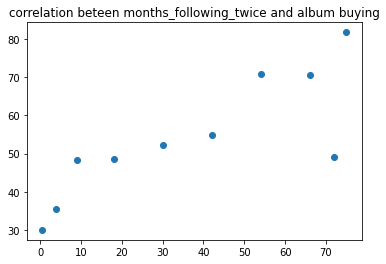

In [256]:
b = 'months_following_twice'
state_office = df_twice_tests.groupby([b, 'Target', ])['What is your current occupation?'].count()


percents_df = state_office.groupby(level=0).apply(lambda x: 100 * x / float(x.sum()))

percents_df = percents_df.reset_index()

percents_df = percents_df[percents_df['Target']==True]

percents_df['log_{}'.format(b)] = np.log(percents_df[b])

percents_df.replace([np.inf, -np.inf], -1, inplace=True)

#percents_df


#x = percents_df['log_{}'.format(b)]
x = percents_df[b]


y = percents_df['What is your current occupation?']

corr, p_value = stats.pearsonr(x, y)
print("correlation {}".format(corr), b)

plt.scatter(x, y)
plt.title("correlation beteen {} and {}".format(b, "album buying"))
plt.show()

correlation 0.7258671836382644 age_est


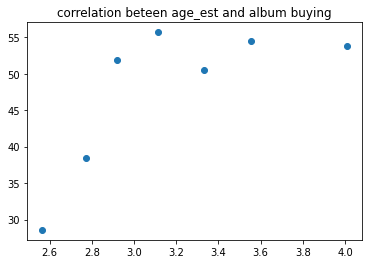

In [257]:
b = 'age_est'
state_office = df_twice_tests.groupby([b, 'Target', ])['What is your current occupation?'].count()


percents_df = state_office.groupby(level=0).apply(lambda x: 100 * x / float(x.sum()))

percents_df = percents_df.reset_index()

percents_df = percents_df[percents_df['Target']==True]

percents_df['log_{}'.format(b)] = np.log(percents_df[b])

percents_df.replace([np.inf, -np.inf], -1, inplace=True)

#percents_df


x = percents_df['log_{}'.format(b)]
#x = percents_df[b]


y = percents_df['What is your current occupation?']

corr, p_value = stats.pearsonr(x, y)
print("correlation {}".format(corr), b)


plt.scatter(x, y)
plt.title("correlation beteen {} and {}".format(b, "album buying"))
plt.show()

In [258]:
df_twice_tests['log_age_est'] = np.log(df_twice_tests['age_est'])

In [259]:
#df_twice_tests

In [260]:
#pd.get_dummies(df_twice_tests[], prefix='What is your favorite content on the r/Twice subreddit? ')

In [261]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [285]:
b = "Who is your bias (Favorite Twice Member) or current favorite member (if you don't have a bias)?"
#"Who is your bias wrecker (Someone that makes you rethink who your bias is)?"
X = df_twice_tests[['log_age_est', 'employed', 'male', 'visits_per_month', 'months_following_twice',
                   'JYPE_Stan', b, 'Did Twice get you into k-pop?' ,
                    
                  # 'What is your favorite content on the r/Twice subreddit? ', "Who is your bias (Favorite Twice Member) or current favorite member (if you don't have a bias)?"
                   
                   ]]
#X = StandardScaler().fit_transform(X)
y = df_twice_tests['Target']

In [286]:
X

,log_age_est,employed,male,visits_per_month,months_following_twice,JYPE_Stan,Who is your bias (Favorite Twice Member) or current favorite member (if you don't have a bias)?,Did Twice get you into k-pop?
0,3.113515,0,0,3,66.0,0,Momo,0
1,3.555348,1,1,150,9.0,0,Mina,0
2,3.113515,0,1,150,18.0,0,Sana,1
3,3.555348,1,1,150,4.0,0,Sana,0
4,3.113515,1,1,4,75.0,1,Jihyo,0
...,...,...,...,...,...,...,...,...
900,3.555348,1,0,12,75.0,0,Momo,0
901,3.332205,1,1,3,54.0,0,Jihyo,0
902,3.113515,1,1,12,30.0,0,Sana,1
903,3.113515,0,1,3,30.0,1,Mina,1


In [287]:
#X = pd.get_dummies(X, prefix=['What is your favorite content on the r/Twice subreddit? ', "Who is your bias (Favorite Twice Member) or current favorite member (if you don't have a bias)?"])

X = pd.get_dummies(X, prefix=b)





In [288]:
X

,log_age_est,employed,male,visits_per_month,months_following_twice,JYPE_Stan,Did Twice get you into k-pop?,Who is your bias (Favorite Twice Member) or current favorite member (if you don't have a bias)?_Chaeyoung,Who is your bias (Favorite Twice Member) or current favorite member (if you don't have a bias)?_Dahyun,Who is your bias (Favorite Twice Member) or current favorite member (if you don't have a bias)?_Jeongyeon,Who is your bias (Favorite Twice Member) or current favorite member (if you don't have a bias)?_Jihyo,Who is your bias (Favorite Twice Member) or current favorite member (if you don't have a bias)?_Mina,Who is your bias (Favorite Twice Member) or current favorite member (if you don't have a bias)?_Momo,Who is your bias (Favorite Twice Member) or current favorite member (if you don't have a bias)?_Nayeon,Who is your bias (Favorite Twice Member) or current favorite member (if you don't have a bias)?_Sana,Who is your bias (Favorite Twice Member) or current favorite member (if you don't have a bias)?_Tzuyu
0,3.113515,0,0,3,66.0,0,0,0,0,0,0,0,1,0,0,0
1,3.555348,1,1,150,9.0,0,0,0,0,0,0,1,0,0,0,0
2,3.113515,0,1,150,18.0,0,1,0,0,0,0,0,0,0,1,0
3,3.555348,1,1,150,4.0,0,0,0,0,0,0,0,0,0,1,0
4,3.113515,1,1,4,75.0,1,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
900,3.555348,1,0,12,75.0,0,0,0,0,0,0,0,1,0,0,0
901,3.332205,1,1,3,54.0,0,0,0,0,0,1,0,0,0,0,0
902,3.113515,1,1,12,30.0,0,1,0,0,0,0,0,0,0,1,0
903,3.113515,0,1,3,30.0,1,1,0,0,0,0,1,0,0,0,0


In [289]:
X.shape

(845, 16)

In [290]:
y.shape

(845,)

In [291]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [292]:
neigh = KNeighborsClassifier(n_neighbors=8)
neigh.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=8)

In [293]:
neigh.score(X_test, y_test)

0.5663082437275986

In [294]:
clf = LogisticRegression(random_state=0)#.fit(X, y)
clf.fit(X_train, y_train)

/Users/nicolascap/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:764: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


LogisticRegression(random_state=0)

In [295]:
clf.score(X_test, y_test)

0.5878136200716846